In [1]:
# Assignment problem_Minimize cost
# 3 workers assigned to 3 tasks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment

In [2]:
# cost matrix 

cost = np.array([[9,2,7],
                 [3,6,4],
                 [1,8,5]])

# display as DataFrame
df_cost = pd.DataFrame(cost,
                      index =["worker1","worker2","worker3"],
                      columns = ["task1","task2","task3"])

print("======cost matrix======")
print(df_cost)

======cost matrix======
         task1  task2  task3
worker1      9      2      7
worker2      3      6      4
worker3      1      8      5


In [3]:
# solve assignment problem

row_ind, col_ind = linear_sum_assignment(cost)

print("====optimal assignment===")

tasks  = ["task1","task2","task3"]
workers= ["worker1","worker2","worker3"]

total_cost=0
for i in range(len(row_ind)):
    worker      = workers[row_ind[i]]
    task        = tasks[col_ind[i]]
    cost_i      = cost[row_ind[i],col_ind[i]]
    total_cost += cost_i
    print(f"{worker} -> {task} : {cost_i}")

print(f"\n min total cost : {total_cost}") 

====optimal assignment===
worker1 -> task2 : 2
worker2 -> task3 : 4
worker3 -> task1 : 1

 min total cost : 7


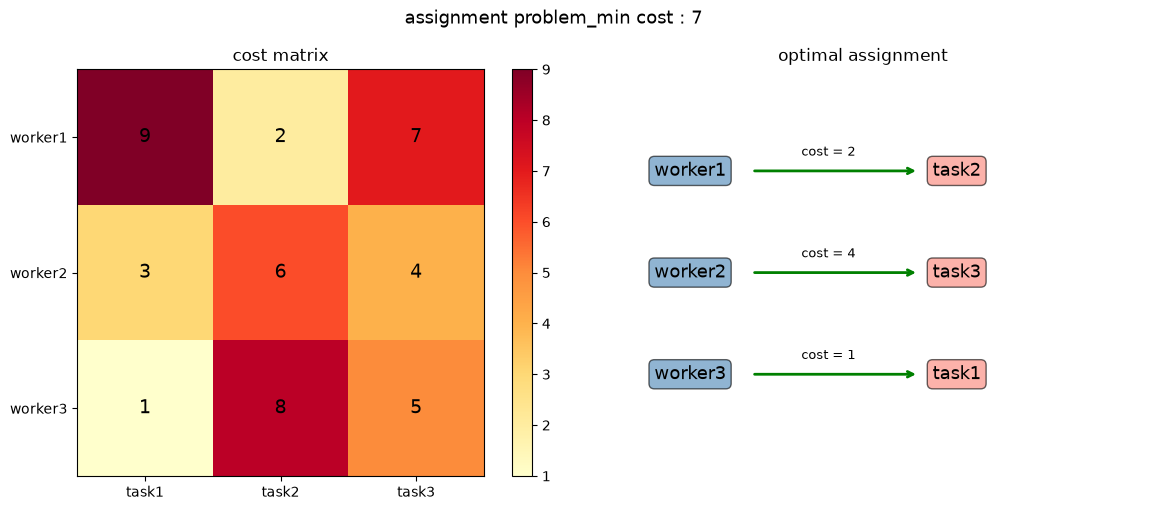

In [6]:
# visualization

fig , axes =  plt.subplots(1 , 2 , figsize= (12,5))

#------ 1) cost matrix heatmap

ax1  =  axes[0]
im   =  ax1.imshow (cost , cmap = "YlOrRd") 

ax1.set_xticks([0,1,2])
ax1.set_yticks([0,1,2])

ax1.set_xticklabels(["task1","task2","task3"])
ax1.set_yticklabels(["worker1","worker2","worker3"])

ax1.set_title("cost matrix")

for i in range(3):
    for j in range(3):
        ax1.text(j,i,cost[i,j],ha="center",va="center",fontsize=14)

plt.colorbar(im , ax=ax1)


# ------ 2) optimal anigment ---------

ax2=axes[1]

ax2.set_xlim(0,4)
ax2.set_ylim(0,4)

ax2.axis("off")

ax2.set_title("optimal assignment")

for i in range(len(row_ind)):
    worker = workers[row_ind[i]]
    task   = tasks[col_ind[i]]
    cost_i = cost[row_ind[i],col_ind[i]] 
    
    y      = 3 - i
    ax2.text(0.5 , y , worker , fontsize = 13 , va = "center" , 
            bbox = dict(boxstyle = "round" , facecolor = "steelblue" ,alpha=0.6) )

    ax2.text( 2.5 , y , task , fontsize = 13 , va = "center" ,
            bbox = dict(boxstyle = "round" , facecolor = "salmon" ,alpha=0.6) )

    ax2.annotate ("", xy=(2.4 , y) , xytext= (1.2 , y) , 
            arrowprops = dict (arrowstyle = "->" , color = "green" , lw=2))

    ax2.text(1.75 , y + 0.15 , f"cost = {cost_i}" , fontsize = 9 , ha= "center")

plt.suptitle(f"assignment problem_min cost : {total_cost} ",fontsize= 13)

plt.tight_layout()
plt.show()

In [8]:
# Result summary

results={
    "worker":[workers[row_ind[i]] for i in range(len(row_ind))],
    "task":[tasks[col_ind[i]] for i in range(len(col_ind))],
    "cost":[cost[row_ind[i],col_ind[i]] for i in range(len(row_ind))]
}

df_results = pd.DataFrame(results)
print("====== optimal assignment======")
print(df_results)
print(f"\n min total cost : {total_cost}")

====== optimal assignment======
    worker   task  cost
0  worker1  task2     2
1  worker2  task3     4
2  worker3  task1     1

 min total cost : 7
